In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
parent_dir = os.path.join(os.getcwd(), '..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from module.retail_pipeline import RetailSimulationPipeline, BasketDataset, ProductRecommenderNN
import seaborn as sns
from sklearn.metrics import jaccard_score, mean_squared_error

# 貼上你提供的 RetailSimulationPipeline, BasketDataset, ProductRecommenderNN 類別
# (此處省略重複的原始碼，請確保在 Notebook 中已執行你的原始定義)

# --- 1. 生成資料與切分 ---
pipeline = RetailSimulationPipeline(n_transactions=5000)
df = pipeline.generate_transactions()
X, Y, med_to_idx, prod_to_idx = pipeline.prepare_tensors()

# 切分 Train / Test (80/20)
dataset = BasketDataset(X, Y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

input_dim = X.shape[1]
num_products = Y.shape[1]

In [2]:
class ConditionalNoisePredictor(nn.Module):
    """預測加入的雜訊 epsilon"""
    def __init__(self, target_dim, cond_dim, time_dim=16):
        super().__init__()
        self.time_dim = time_dim
        # 簡單的 MLP 架構
        self.net = nn.Sequential(
            nn.Linear(target_dim + cond_dim + time_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, target_dim)
        )
        
    def forward(self, y_t, cond, t):
        # 簡單的時間嵌入 (Sine/Cosine)
        t_emb = torch.cat([torch.sin(t / 100.0), torch.cos(t / 100.0)], dim=-1)
        t_emb = t_emb.repeat(1, self.time_dim // 2)
        
        x = torch.cat([y_t, cond, t_emb], dim=-1)
        return self.net(x)

class TabularDiffusionModel(nn.Module):
    """簡化的條件 DDPM 推薦模型"""
    def __init__(self, target_dim, cond_dim, n_steps=100):
        super().__init__()
        self.n_steps = n_steps
        self.target_dim = target_dim
        self.predictor = ConditionalNoisePredictor(target_dim, cond_dim)
        
        # 建立 Noise Schedule (Beta)
        self.register_buffer('beta', torch.linspace(1e-4, 0.02, n_steps))
        self.register_buffer('alpha', 1. - self.beta)
        self.register_buffer('alpha_bar', torch.cumprod(self.alpha, dim=0))
        
    def forward_process(self, y_0, t):
        """加入雜訊 q(y_t | y_0)"""
        noise = torch.randn_like(y_0)
        a_bar = self.alpha_bar[t].view(-1, 1)
        y_t = torch.sqrt(a_bar) * y_0 + torch.sqrt(1 - a_bar) * noise
        return y_t, noise
        
    def forward(self, y_0, cond):
        """訓練階段：隨機抽樣 t 並預測雜訊"""
        t = torch.randint(0, self.n_steps, (y_0.shape[0],), device=y_0.device)
        y_t, target_noise = self.forward_process(y_0, t)
        pred_noise = self.predictor(y_t, cond, t.unsqueeze(1).float())
        return pred_noise, target_noise
    
    @torch.no_grad()
    def sample(self, cond):
        """推論階段：從純雜訊逐步去噪"""
        b_size = cond.shape[0]
        y_t = torch.randn((b_size, self.target_dim), device=cond.device)
        
        for i in reversed(range(self.n_steps)):
            t = torch.full((b_size, 1), i, device=cond.device, dtype=torch.float)
            pred_noise = self.predictor(y_t, cond, t)
            
            a = self.alpha[i]
            a_bar = self.alpha_bar[i]
            beta = self.beta[i]
            
            # 去噪推導式
            y_t = (1 / torch.sqrt(a)) * (y_t - (1 - a) / torch.sqrt(1 - a_bar) * pred_noise)
            if i > 0:
                y_t += torch.sqrt(beta) * torch.randn_like(y_t)
                
        # 將最終結果限制在 [0, 1] 區間作為機率分布的替代
        return torch.clamp(y_t, 0.0, 1.0)

In [3]:
# 初始化模型
baseline_nn = ProductRecommenderNN(input_dim, num_products)
diffusion_nn = TabularDiffusionModel(target_dim=num_products, cond_dim=input_dim, n_steps=50)

# 優化器
opt_base = optim.Adam(baseline_nn.parameters(), lr=0.005)
opt_diff = optim.Adam(diffusion_nn.parameters(), lr=0.005)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

epochs = 30
print("開始訓練 Baseline 與 Diffusion Models...")

for ep in range(epochs):
    baseline_nn.train()
    diffusion_nn.train()
    loss_b, loss_d = 0.0, 0.0
    
    for bx, by in train_loader:
        # Train Baseline
        opt_base.zero_grad()
        logits = baseline_nn(bx)
        lb = criterion_bce(logits, by)
        lb.backward()
        opt_base.step()
        loss_b += lb.item()
        
        # Train Diffusion
        opt_diff.zero_grad()
        pred_noise, target_noise = diffusion_nn(by, bx) # 擴散模型的 Target 是 Y，條件是 X
        ld = criterion_mse(pred_noise, target_noise)
        ld.backward()
        opt_diff.step()
        loss_d += ld.item()
        
    if (ep + 1) % 10 == 0:
        print(f"Epoch {ep+1:02d} | Baseline BCE Loss: {loss_b/len(train_loader):.4f} | Diffusion MSE Loss: {loss_d/len(train_loader):.4f}")

print("訓練完成。")

開始訓練 Baseline 與 Diffusion Models...
Epoch 10 | Baseline BCE Loss: 0.3969 | Diffusion MSE Loss: 0.4585
Epoch 20 | Baseline BCE Loss: 0.3747 | Diffusion MSE Loss: 0.3867
Epoch 30 | Baseline BCE Loss: 0.3674 | Diffusion MSE Loss: 0.3584
訓練完成。


In [4]:
# 初始化模型
baseline_nn = ProductRecommenderNN(input_dim, num_products)
diffusion_nn = TabularDiffusionModel(target_dim=num_products, cond_dim=input_dim, n_steps=50)

# 優化器
opt_base = optim.Adam(baseline_nn.parameters(), lr=0.005)
opt_diff = optim.Adam(diffusion_nn.parameters(), lr=0.005)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

epochs = 30
print("開始訓練 Baseline 與 Diffusion Models...")

for ep in range(epochs):
    baseline_nn.train()
    diffusion_nn.train()
    loss_b, loss_d = 0.0, 0.0
    
    for bx, by in train_loader:
        # Train Baseline
        opt_base.zero_grad()
        logits = baseline_nn(bx)
        lb = criterion_bce(logits, by)
        lb.backward()
        opt_base.step()
        loss_b += lb.item()
        
        # Train Diffusion
        opt_diff.zero_grad()
        pred_noise, target_noise = diffusion_nn(by, bx) # 擴散模型的 Target 是 Y，條件是 X
        ld = criterion_mse(pred_noise, target_noise)
        ld.backward()
        opt_diff.step()
        loss_d += ld.item()
        
    if (ep + 1) % 10 == 0:
        print(f"Epoch {ep+1:02d} | Baseline BCE Loss: {loss_b/len(train_loader):.4f} | Diffusion MSE Loss: {loss_d/len(train_loader):.4f}")

print("訓練完成。")

開始訓練 Baseline 與 Diffusion Models...
Epoch 10 | Baseline BCE Loss: 0.3887 | Diffusion MSE Loss: 0.4570
Epoch 20 | Baseline BCE Loss: 0.3717 | Diffusion MSE Loss: 0.3887
Epoch 30 | Baseline BCE Loss: 0.3635 | Diffusion MSE Loss: 0.3629
訓練完成。


,Model,Accuracy (Exact Match),Precision,Recall,Jaccard Index,Mean Absolute Error,Global MSE
0,Baseline NN,0.163,0.482833,0.394167,0.343567,0.243323,0.121023
1,Tabular Diffusion,0.047,0.299000,0.265867,0.197717,0.285858,0.223260


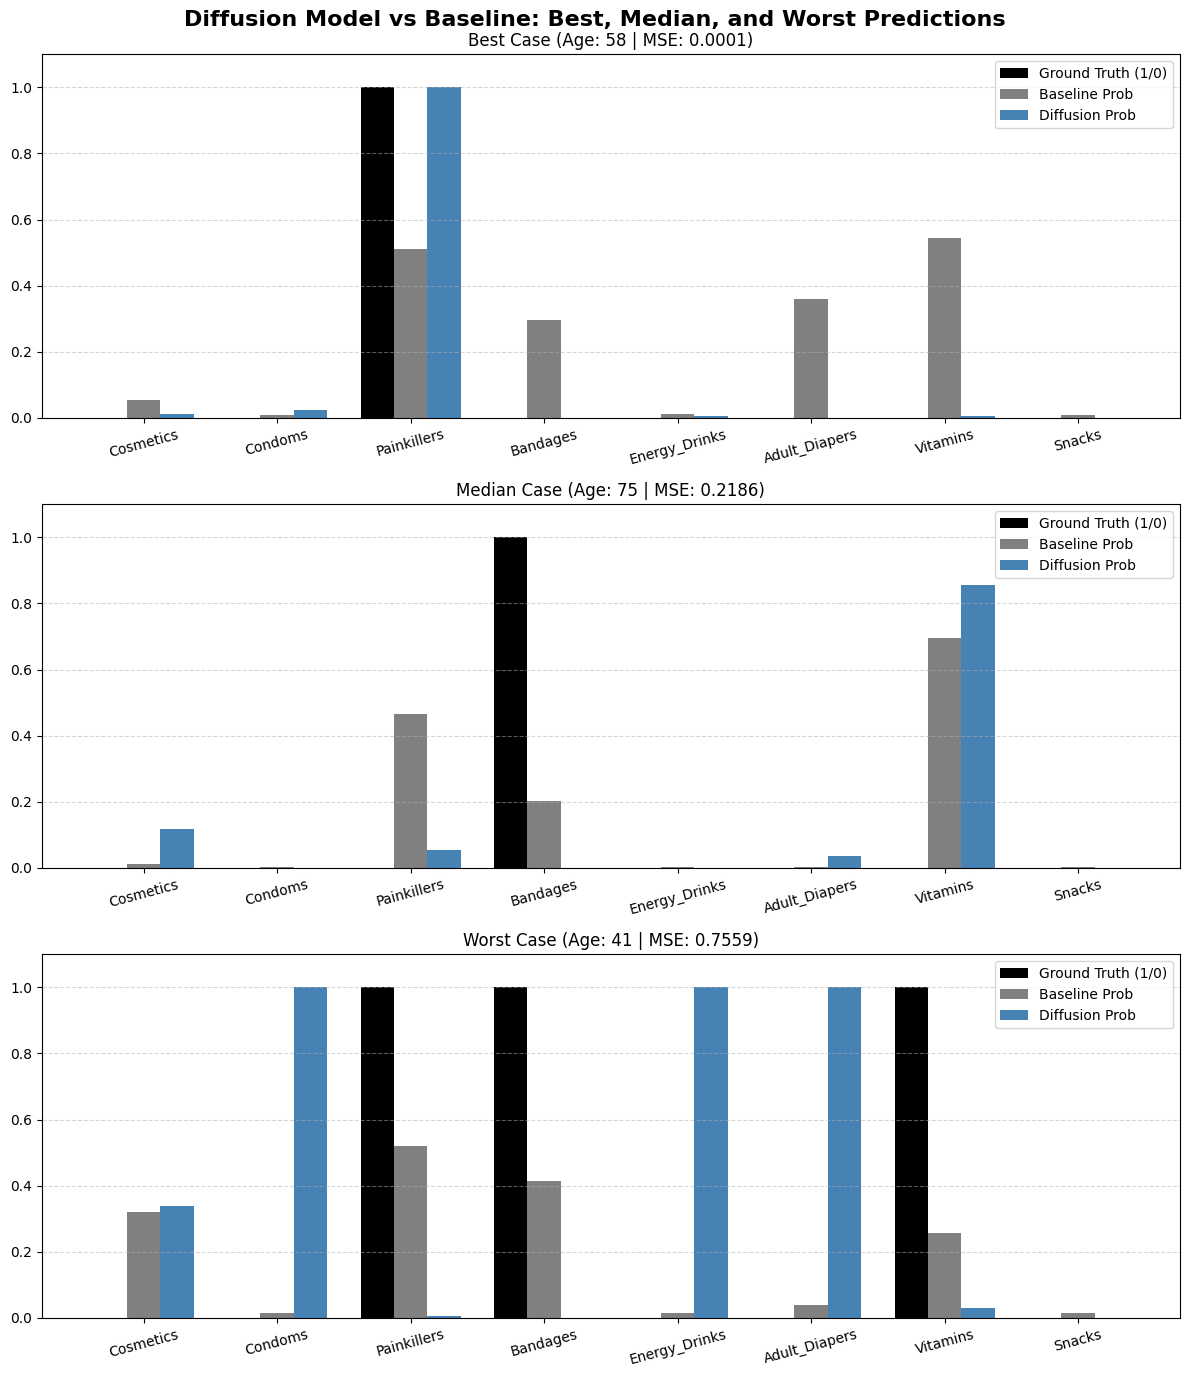

In [6]:
from sklearn.metrics import jaccard_score, mean_squared_error, precision_score, recall_score, accuracy_score
import warnings

# 忽略因為某些極端 case 導致的無害警告 (確保版面乾淨)
warnings.filterwarnings('ignore', category=UserWarning)

baseline_nn.eval()
diffusion_nn.eval()

all_targets = []
base_preds = []
diff_preds = []
cond_features = []

# 收集推論結果
with torch.no_grad():
    for bx, by in test_loader:
        all_targets.append(by.numpy())
        cond_features.append(bx.numpy())
        
        # Baseline 推論 (Sigmoid 轉機率)
        b_prob = torch.sigmoid(baseline_nn(bx)).numpy()
        base_preds.append(b_prob)
        
        # Diffusion 推論 (透過反向去噪過程)
        d_prob = diffusion_nn.sample(bx).numpy()
        diff_preds.append(d_prob)

all_targets = np.vstack(all_targets)
base_preds = np.vstack(base_preds)
diff_preds = np.vstack(diff_preds)
cond_features = np.vstack(cond_features)

# 計算每個 Sample 的 MSE 誤差 (越小越準)
base_errors = np.mean((base_preds - all_targets)**2, axis=1)
diff_errors = np.mean((diff_preds - all_targets)**2, axis=1)

# 將機率轉換為 0/1 的二元預測 (Threshold = 0.5)
base_preds_bin = (base_preds > 0.5).astype(int)
diff_preds_bin = (diff_preds > 0.5).astype(int)

# --- 產生 Overview DataFrame (加入 Precision, Recall, Accuracy) ---
# 使用 average='samples' 來評估多標籤推薦的購物籃準確度，並加入 zero_division=0 消除警告
metrics = {
    "Model": ["Baseline NN", "Tabular Diffusion"],
    "Accuracy (Exact Match)": [
        accuracy_score(all_targets, base_preds_bin),
        accuracy_score(all_targets, diff_preds_bin)
    ],
    "Precision": [
        precision_score(all_targets, base_preds_bin, average='samples', zero_division=0),
        precision_score(all_targets, diff_preds_bin, average='samples', zero_division=0)
    ],
    "Recall": [
        recall_score(all_targets, base_preds_bin, average='samples', zero_division=0),
        recall_score(all_targets, diff_preds_bin, average='samples', zero_division=0)
    ],
    "Jaccard Index": [
        jaccard_score(all_targets, base_preds_bin, average='samples', zero_division=0),
        jaccard_score(all_targets, diff_preds_bin, average='samples', zero_division=0)
    ],
    "Mean Absolute Error": [
        np.mean(np.abs(base_preds - all_targets)),
        np.mean(np.abs(diff_preds - all_targets))
    ],
    "Global MSE": [
        np.mean(base_errors),
        np.mean(diff_errors)
    ]
}
overview_df = pd.DataFrame(metrics)
display(overview_df)

# --- 尋找 Diffusion 模型的 Best, Median, Worst 案例 ---
sorted_indices = np.argsort(diff_errors)
best_idx = sorted_indices[0]         # 誤差最小
median_idx = sorted_indices[len(sorted_indices)//2] # 誤差中位
worst_idx = sorted_indices[-1]       # 誤差最大

cases = [
    ("Best Case", best_idx),
    ("Median Case", median_idx),
    ("Worst Case", worst_idx)
]

# --- 繪製視覺化圖表 ---
products = pipeline.products
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle("Diffusion Model vs Baseline: Best, Median, and Worst Predictions", fontsize=16, fontweight='bold')

for ax, (title, idx) in zip(axes, cases):
    x_axis = np.arange(len(products))
    width = 0.25
    
    # 提取年齡資訊 (反正規化)
    age = int(cond_features[idx][0] * 100)
    
    ax.bar(x_axis - width, all_targets[idx], width, label='Ground Truth (1/0)', color='black')
    ax.bar(x_axis, base_preds[idx], width, label='Baseline Prob', color='gray')
    ax.bar(x_axis + width, diff_preds[idx], width, label='Diffusion Prob', color='steelblue')
    
    ax.set_title(f"{title} (Age: {age} | MSE: {diff_errors[idx]:.4f})", fontsize=12)
    ax.set_xticks(x_axis)
    ax.set_xticklabels(products, rotation=15)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()